# Applied Time Series Analysis System

## Notebook 01: Data Collection and Preparation

### Purpose

This notebook imports and prepares monthly global climate anomaly data for statistical time series analysis.

### Objectives

- Load the dataset
- Assess data quality
- Convert date variables
- Create a time-indexed series
- Produce initial visualizations

### Expected Outcome

A cleaned and properly indexed climate time series ready for exploratory analysis, decomposition, stationarity testing, and forecasting.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12,6)

In [2]:
df = pd.read_csv("/content/monthly_csv.csv")

df.head()

,Source,Date,Mean
0,GCAG,2016-12-06,0.7895
1,GISTEMP,2016-12-06,0.8100
2,GCAG,2016-11-06,0.7504
3,GISTEMP,2016-11-06,0.9300
4,GCAG,2016-10-06,0.7292


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape: (3288, 3)

Columns:
['Source', 'Date', 'Mean']

Data Types:
Source     object
Date       object
Mean      float64
dtype: object


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3288 entries, 0 to 3287
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Source  3288 non-null   object 
 1   Date    3288 non-null   object 
 2   Mean    3288 non-null   float64
dtypes: float64(1), object(2)
memory usage: 77.2+ KB


## Missing Value Assessment

This section evaluates the completeness of the dataset and identifies any potential data quality issues that may affect subsequent statistical analysis.

In [5]:
missing = df.isnull().sum()

missing.to_frame(name="Missing Values")

,Missing Values
Source,0
Date,0
Mean,0


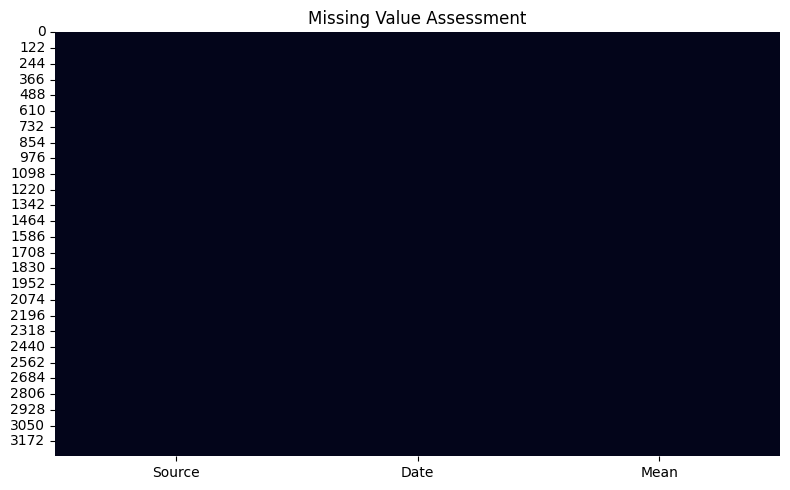

In [6]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Value Assessment")

plt.tight_layout()

plt.savefig(
    "missing_values.png",
    dpi=300
)

plt.show()

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

df.dtypes

,0
Source,object
Date,datetime64[ns]
Mean,float64


In [8]:
df["Source"].value_counts()

,count
Source,
GCAG,1644
GISTEMP,1644


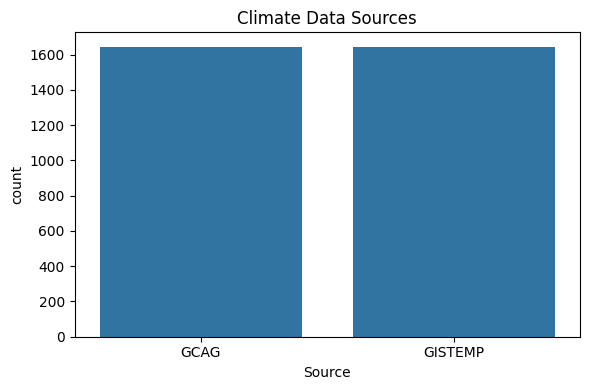

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Source"
)

plt.title("Climate Data Sources")

plt.tight_layout()

plt.savefig(
    "source_distribution.png",
    dpi=300
)

plt.show()

In [10]:
climate = (
    df.groupby("Date")["Mean"]
      .mean()
      .reset_index()
)

climate.head()

,Date,Mean
0,1880-01-06,-0.14955
1,1880-02-06,-0.16645
2,1880-03-06,-0.15785
3,1880-04-06,-0.15995
4,1880-05-06,-0.10690


In [11]:
climate = climate.sort_values("Date")

climate.set_index(
    "Date",
    inplace=True
)

climate.head()

,Mean
Date,
1880-01-06,-0.14955
1880-02-06,-0.16645
1880-03-06,-0.15785
1880-04-06,-0.15995
1880-05-06,-0.10690


In [12]:
climate.describe()

,Mean
count,1644.000000
mean,0.036588
std,0.333718
min,-0.684800
25%,-0.210275
50%,-0.036200
75%,0.238513
max,1.271050


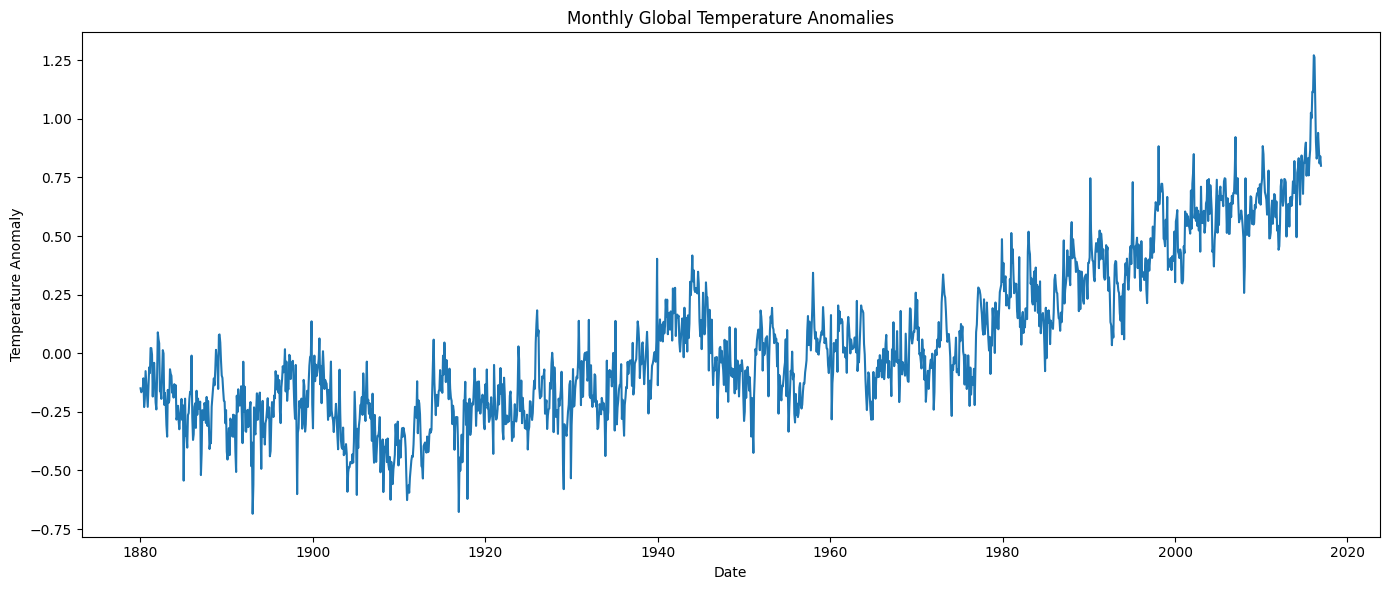

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    climate.index,
    climate["Mean"]
)

plt.title(
    "Monthly Global Temperature Anomalies"
)

plt.xlabel("Date")

plt.ylabel("Temperature Anomaly")

plt.tight_layout()

plt.savefig(
    "initial_time_series.png",
    dpi=300
)

plt.show()